랜덤포레스트는 그냥 해본것에 의미~!

트리계열이니까  shap 분석!!

함수 제시


max_feature 1.0 > 다 가지고 해봐라!


여러개의 추정기가 동시에 움직이니 병렬 처리 필요

트리계열이라 스케일링 불피료!

verbose = 1 : 하이퍼 파라미터 튜닝 작업을 알려줌 , 0 은 생략



랜덤포레스트는 과적합 거의다 발생해서 잘 못씀....


hs_feature_importance

-knn, scr 은 permutation importance 로만 봐야하고

인사이트...

나중에 상호작용 표에서 core 인 항목들로만 볼 수 있게 되는 것

===========
결과표 보면


core 인 애들로만 dependence plot 만들고,,,
bool = true 하면 모든 순서쌍


stable 은 볼 필요 없어서 변동성 variable 로 봄


행단위로 반복을 돌면사,,,,feature에 ㄷ해당하는 값을 키로 던져줘서..

{변수 이름:0,1,2,3,} >> 이걸 순위로 씁니다


변수쌍 정렬에 쓰는 함수



sorted 에 리스트 던졌을 때, 그 기준을 key..

(b,a ) >x 로 가
딕셔너리의 get > x
b 가 없으면 뒤의 999 기본 값으로 가져오는거


랭킹이 없으면 999, b가 들어오면 0 


그렇게 pairs 가 만들어지고....
구조분해 해서 하나씩뽑으면...

# [LAB 08] 지도학습 > 예측 > 앙상블 > 03.Bagging RandomForest


## #01. 랜던 포레스트 개요
- 의사결정나무 여러개를 결합한 배깅 기반의 앙상블 회귀 모델
- 개별 나무의 에측값을 평균하여 최종 예측값 생성
- 단일 트리의 과적합 문제를 완화하는 것이 핵심적인 목표


## #02. 준비 작업
### [1] 패키지 참조

In [45]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from itertools import product

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor

from pandas import merge
# 신규 - 설치 필요 (pip install --upgrade shap)
import shap

### [2] 성능 평가 함수 정의
- hs_get_scores()
- hs_learning_cv()
- hs_get_score_cv()
- hs_feature_importance(model , x_train, y_train) : SVM 예제

### [3] 데이터 가져오기 + 인덱스 ,타입변환

In [36]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련,학습 데이터 분리

In [37]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #03. RandomForest 모델 적합

### [1] 주요 하이퍼 파라미터

| 파라미터명 | 핵심도 | 실무 튜닝 전략 요약 | 기본값 | GridSearchCV 실무 권장값 |
|-----------|--------|------------------|--------|------------------------|
| n_estimators | ⭐⭐ | 성능 안정화용, 과도한 탐색 불필요 | 100 | [300, 500] |
| max_depth | ⭐⭐ | 과적합 보조 제어, 제한적 탐색 | None | [None, 10] |
| min_samples_leaf | ⭐⭐⭐ | 과적합 통제 핵심 파라미터 | 1 | [5, 10] |
| max_features | ⭐⭐⭐ | 트리 다양성 핵심, 랜덤포레스트 정체성 | 1.0 | ['sqrt', 1.0] |
| criterion | ⭐ | 노드 분할 품질 측정 기준 | "squared_error" | - |
| n_jobs | ✅ | 병렬 처리 | None | -1 |
| random_state | ✅ | 재현성 확보 | None | 52 |



1. n_estimators
   - 랜덤 포레스트를 구성하는 의사결정나무의 개수
   - 트리수가 많을수록 예측 평균이 안정되지만, 일정 이상부터면 성능 증가 거의 없음
   - 튜닝 목적이면 300-500 이 적절하고, 너무 크면 시간이 오래 걸림
   - 성능 안정화 용 파라미터로, 과적합 조절용은 아님

2. max_depth
   - 하나의 트리가 얼마나 깊게 질문을 이어갈 수 있는가
   - 깊을수록 데이터 과적합 발생
   - 과적합을 제어하는 보조 장치
  
3. min_samples_leaf
   - 최종 예측 노드에 최소 몇 개의 데이터가 있어야 하는지
   - 랜덤 포레스트에서 과적합을 방지하는 가장 중요한 역할을 함
   - 값이 클수록 예측이 부드러워짐
   - 기본값 1 은 무조건 과적합 발생이기 떄문에 5,10 정도를 튜닝시 꼭 넣어함

4. max_features
   - 분할 시 사용할 변수 비율 ( 노드 하나를 분할할 떄, 최대 몇 개의 변수를 후보로 할 것인가)
   - 노드 분할 시 전체 변수 중 일부만 랜덤 선택 > 각 트리마다 성격을 다르게 만들어서, 서로 다른 관점의 나무들이 생성되는것, 이를 평균내면 더 강해짐
   - 트리간 상관관계를 낮춰주고, 앙상블 효과를 높혀줘
   - 변수 갯수의 제곱근을 씌워 그 수만큼 변수를 선택
   - (분류) sqrt로 설정하면, 16개 변수라면 4개씩 골라서 사용 *강한 랜덤성
   - (회귀) 1.0으로 설정하면 모든 변수를 분할로 선택 (모든 변수를 쓰더라도, 부트스트랩은 특성상 중복 허용으로 랜덤 샘플링 되는 구조, 즉 같은 변수들이더라도 보는 조합은 달라질 수 있음)


5. criterion
   - 이 분할이 얼마나 잘 나뉘어 졌는가를 수치로 평가하는 기준
   - 트리는 노드 분할마다 어떤 변수 + 어떤 기준일 때 criterion 이 좋아질 지 고민함
   - (분류) 지니 > 0일수록 완벽 ,  노드 내 클래스가 섞여있는 정도
   - (회귀) squared_error
   - 엔트로피 > 0 일수록 완벽

In [38]:
%%time

# 트리 계열은 값의 크기가 아닌 비교 결과 기반, 스케일링이 필요 없으므로 Pipeline 생략
rf = RandomForestRegressor(
    random_state=52,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500],        # ⭐⭐ 성능 안정화
    "max_depth": [None, 10],           # ⭐⭐ 보조 과적합 제어
    "min_samples_leaf": [5, 10],       # ⭐⭐⭐ 과적합 통제 핵심
    "max_features": ["sqrt", 1.0],     # ⭐⭐⭐ 트리 다양성 핵심
}

gs = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

gs.fit(x_train, y_train)

best_model = gs.best_estimator_
best_model


Fitting 5 folds for each of 16 candidates, totalling 80 fits
CPU times: total: 453 ms
Wall time: 5.05 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### 필요한 함수 정의
#### 성능 평가 함수

In [39]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 변수 중요도 확인

In [40]:
from sklearn.inspection import permutation_importance

def feature_importance(model, x, y):
    perm = permutation_importance(
        estimator=model,
        X=x,
        y=y,
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )

    # 결과 정리
    perm_df = DataFrame(
        {
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        },
        index=x.columns,
    ).sort_values("importance_mean", ascending=False)

    # 시각화
    df = perm_df.sort_values(by="importance_mean", ascending=False)

    figsize = (1280 / my_dpi, 600 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance_mean", y=df.index)

    ax.set_title("Permutation Importance")
    ax.set_xlabel("Permutation Importance (mean)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return perm_df


> 여기서 permutation importance > permutation 은 순열 즉, 순서를 바꾸는 의미로
머신러닝에서는 값을 랜덤하게 섞는 셔플의 개념임

permutation_importance 는, 각 변수들을 랜덤으로 셔플해서 정보력을 꺠뜨려보고
그떄 R2 가 얼마나 떨어지는지를 측정함. 이걸 30번 반복했을 떄의 평균과 표준편차를 계산하는 것


importance_mean 값은 평균 중요도로, 즉 랜덤 셔플했을 때 평균적으로 R2 가 얼마나 떨어졌는지 감소량
importance_Std 는 중요도에 대한 표준편차


> 즉 해당 변수가 없을 떄 예측이 얼마나 힘들어지나로 중요도를 확인하는 것


> 셔플의 예시
> <셔플전>

| index | weekend | sales |
| ----- | ------- | ----- |
| 0     | 0       | 100   |
| 1     | 1       | 300   |
| 2     | 0       | 120   |
| 3     | 1       | 320   |

<셔플후>

| index | weekend (셔플됨) | sales |
| ----- | ------------- | ----- |
| 0     | 1             | 100   |
| 1     | 0             | 300   |
| 2     | 1             | 120   |
| 3     | 0             | 320   |

- 모델 입장에서: weekend가 더 이상 sales를 설명해주지 못함
- 랜덤 셔플 = 값은 그대로 두고, 행과의 연결만 끊는 것

#### 과적합 판정 함수

In [41]:
import matplotlib.pyplot as plt

my_dpi = 100  # 없으면 기본값

def create_figure(figsize=(1280/100, 720/100), dpi=None):
    if dpi is None:
        dpi = my_dpi
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax

def finalize_plot(ax):
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


In [42]:
def hs_learning_cv(
    estimator, x, y, scoring="neg_root_mean_squared_error",
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
):

    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 정량 판정
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과소적합 기준선 (some_threshold)
    # -------------------------

    # 기준모형 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    # → 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도의 성능은 내야 한다는 기준을 설정하는 것
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "⚠️ 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "⚠️ 과대적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "⚠️ 데이터 부족 / 분산 큼"
    else:
        status = "⚠️ 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "Train RMSE": [final_train],
            "CV RMSE 평균": [final_cv],
            "CV RMSE 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------

    fig, ax = create_figure()

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    ax.set_xlabel("RMSE", fontsize=8, labelpad=5)  # type: ignore
    ax.set_ylabel("학습곡선 (Learning Curve)", fontsize=8, labelpad=5)  # type: ignore
    ax.grid(True, alpha=0.3)  # type: ignore

    finalize_plot(ax)

    return result_df


#### 성능평가 + 과적합 판정 동시 수행 함수

In [46]:
def hs_get_score_cv(
    estimator,
    x_test,
    y_test,
    x_origin,
    y_origin,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    score_df = hs_get_scores(estimator, x_test, y_test)

    cv_df = hs_learning_cv(
        estimator,
        x_origin,
        y_origin,
        scoring=scoring,
        cv=cv,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    return merge(score_df, cv_df, left_index=True, right_index=True)


## #04. 성능평가

,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
RandomForestRegressor,0.859,0.111,0.021,0.144,0.007,-0.009,0.147,0.213,0.015,0.689,0.072,⚠️ 과대적합 (variance 큼)


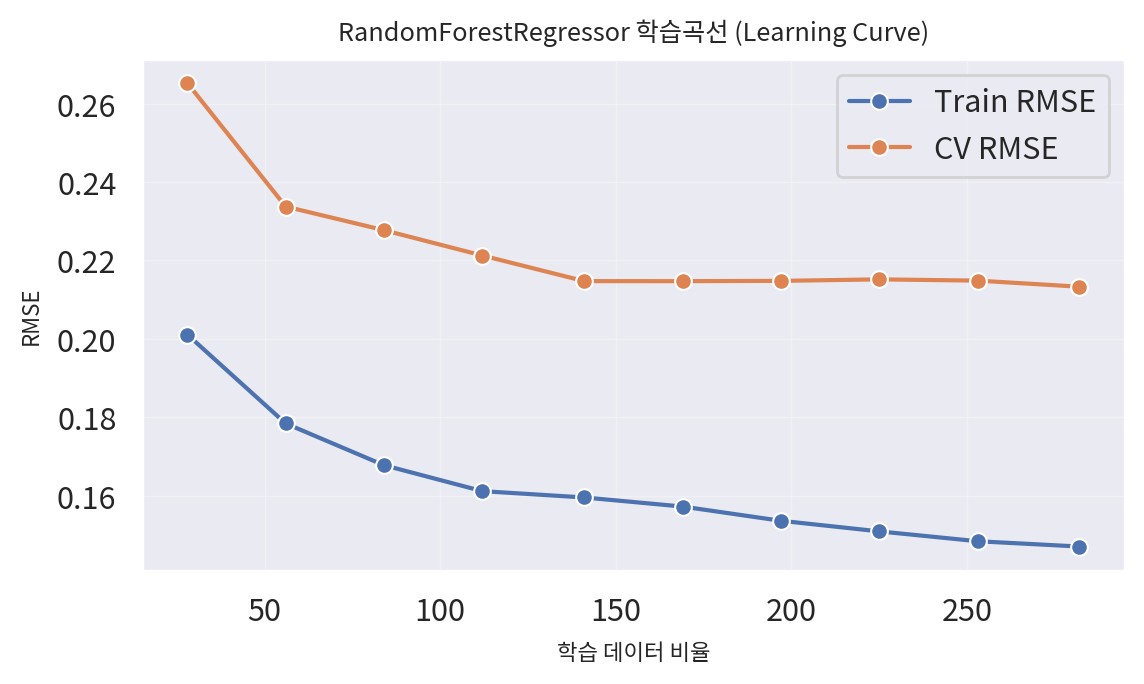

In [47]:
hs_get_score_cv(best_model,x_train,y_train,x,y)

#### 인사이트
> 모델이 훈련 데이터를 지나치게 잘 설명하고 있는 과적합으로, 검증 데이터로 일반화될 떄 성능이 크게 흔들리는 것 확인
> 랜덤포레스트의 전형적인 과적합 패턴

## #05. 결과 해석
### [1] 변수 중요도 판별



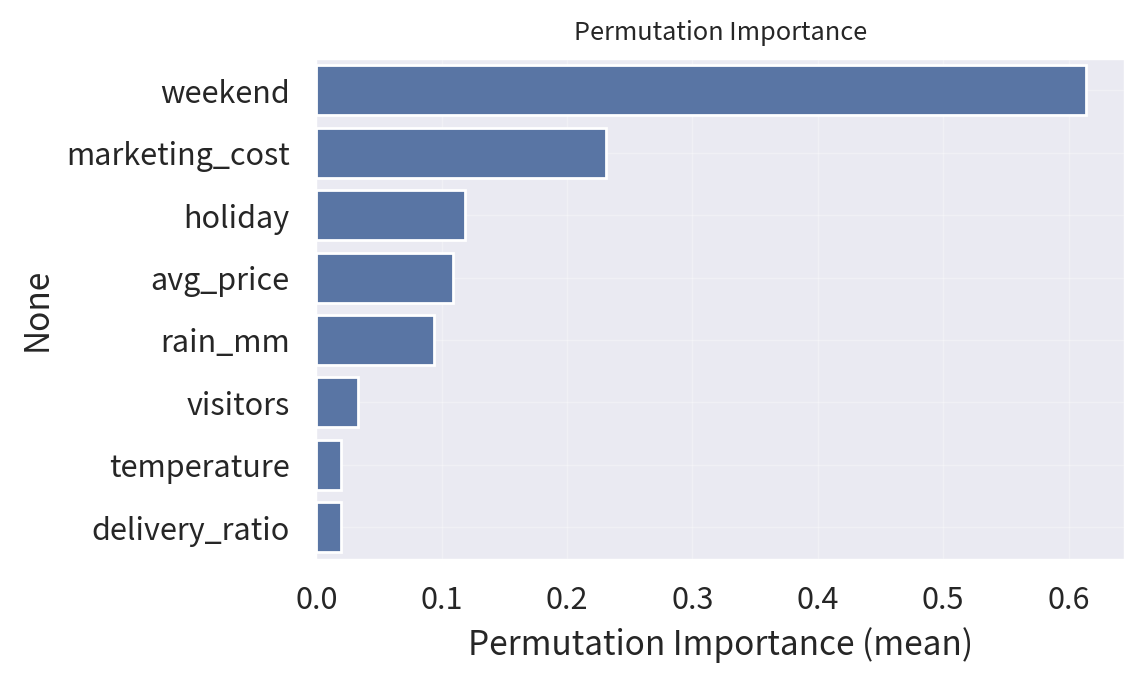

,importance_mean,importance_std,importance_cumsum
weekend,0.613,0.064,0.613
marketing_cost,0.231,0.027,0.844
holiday,0.119,0.016,0.963
avg_price,0.109,0.014,1.073
rain_mm,0.094,0.009,1.166
visitors,0.033,0.004,1.200
temperature,0.020,0.002,1.219
delivery_ratio,0.020,0.002,1.239


In [49]:
hs_feature_importance(best_model,x_train,y_train)

#### 인사이트

| 변수명 | 변수별 인사이트 |
|---|---|
| weekend | 전체 중요도의 약 61%를 차지하는 핵심 변수로, 모델이 주말/비주말 구분에 매우 강하게 의존하고 있어 설명력은 높지만 과대적합 위험과도 직접 연결됨. |
| marketing_cost | 누적 설명력의 84%를 형성하는 2순위 핵심 변수로, 마케팅 비용이 종속변수에 안정적이고 직접적인 영향을 미치는 주요 조절 변수로 해석됨. |
| holiday | 주말 변수와 함께 캘린더 효과를 구성하며, 독립적 영향은 있으나 weekend와 중복 설명 가능성이 존재함. |
| avg_price | 가격 효과는 존재하지만 주말·마케팅 변수 대비 영향력이 작아, 가격보다 수요 구조 요인이 더 중요함을 시사함. |
| rain_mm | 기상 변수 중 의미 있는 수준의 중요도를 가지며, 매출·방문에 보조적 영향을 주는 환경 요인으로 해석됨. |
| visitors | 직접에 비해 중요도가 낮아, 방문자 수 효과가 주말·휴일 변수에 흡수되었을 가능성이 큼. |
| temperature | 영향력이 매우 낮아 모델 예측에서 주변 변수 수준에 머물며, 제거해도 성능 변화가 크지 않을 가능성이 있음. |
| delivery_ratio | 가장 낮은 중요도 그룹에 속하며, 현재 모델 구조에서는 설명 기여도가 제한적인 변수로 판단됨. |



* 특정 변수에 대해서만 의존도가 너무 높아지면,트리 계열은 유독 규칙을 더 외워버려서 새로운 데이터가 왔을 떄 다른 변수들이 제역할을 잘 못하게 될 수 있음
* 1가지 지름길만 다니던 자동차가 사고로 다른 길로 가야할 때 길을 잃고,평소에 다른 길도 많이 가본 자동차가 유연하게 대처할 수 있는 것

### [2] SHAP 분석
- SHAP 분석을 통해 각 변수들이 에측 결과에 얼마나, 어떤 방향으로 영향을 줬는지 알 수 있게 되는 것
- permutation importance 가 전역이라면, SHAP 은 전역 + 개별
- SHAP 은 각 예측을 기본값 + 변수들의 기여도 합으로 분해
- 예측값 = 평균 예측값 + 변수1 기여 + 변수 2 이여 ....
- 특정 구간에서만 효과가 있는건지, 다른변수와의 상호 작용도 확인 가능


- SHAP 에서 봐야하는 3가지는
  - SHAP summary plot (전역 중요도 + 방향성) 
  - SHAP dependence plot (특정 변수 값이 커질수록 예측이 커지는지, 작아지는지, 비선형 임계점 확인)
  - 개별 샘플 shap (force, waterfall) 이 예측이 왜 이렇게 나왔는지에 대해 설명

#### SHAP 분석 일괄 처리 함수 정의
<코드 해석>
1. SHAP Explainer
   - 트리 기반 모델 전용 Explainer 를 생성함
2. SHAP VALUE 계산
   - 예측값 = 평균 예측값 + 변수1 기여 + 변수2 기여  + ...
   - 각 샘플에서 해당 변수가 밀어주는 정도
3. SHAP DF 생성
   - 각 샘플과 변수의 기여도 테이블
4. 요약 통계
   - 평균 절대 SHAP : mean abs shap 으로 방향을 무시하고 우선 해당 변수가 전체적으로 얼마나 자주,크게 쓰였는지 확인 permutation importance 랑 가장 비슷한 개념
   - mean_shap (방향성) : 평균적으로 예측을 끌어올리는지 끌어 내리는지 확인
   - std/cv (안정성) 작으면 항상 비슷한 영향, 크면 상황에 따라 영향 달라짐

5. mean_abs_shap 기준 중요도 정렬
6. 누적 80% 기준이 되는 지점 확인하여 core, secondart 로 표시
   - core 는 모델 예측을 주도하며 약화 시 성능 영향이 크고, secondary 는 미세 조정용
7. 시각화
   - 중요도 순서, 영향 방향, 값의 크기 분포, 비선형성, 이상치 영향 확인 가능해짐

In [50]:
def hs_shap_analysis(
    model,
    x: DataFrame,
    plot: bool = True,
    width: int = 1600,
    height: int = 800,
):
    # -------------------------------------------------
    # 1. SHAP Explainer 생성 (트리 모델용)
    # -------------------------------------------------
    explainer = shap.TreeExplainer(model)

    # -------------------------------------------------
    # 2. SHAP 값 계산
    # shape = (n_samples, n_features)
    # -------------------------------------------------
    shap_values = explainer.shap_values(x)

    # -------------------------------------------------
    # 3. SHAP DataFrame 변환
    # -------------------------------------------------
    shap_df = DataFrame(
        shap_values,
        columns=x.columns,
        index=x.index,
    )

    # -------------------------------------------------
    # 4. SHAP 요약 통계
    # -------------------------------------------------
    summary_df = DataFrame(
        {
            "feature": shap_df.columns,
            "mean_abs_shap": shap_df.abs().mean().values,
            "mean_shap": shap_df.mean().values,
            "std_shap": shap_df.std().values,
        }
    )

    # -------------------------------------------------
    # 5. 영향 방향 (보수적 기준)
    # -------------------------------------------------
    summary_df["direction"] = np.where(
        summary_df["mean_shap"] > 0,
        "양(+) 경향",
        np.where(summary_df["mean_shap"] < 0, "음(-) 경향", "혼합/미약"),
    )

    # -------------------------------------------------
    # 6. 변동성 지표 (안정성 판단)
    # -------------------------------------------------
    summary_df["cv"] = (
        summary_df["std_shap"] / (summary_df["mean_abs_shap"] + 1e-9)
    )

    summary_df["variability"] = np.where(
        summary_df["cv"] < 1,
        "stable",      # 평균 대비 변동성 낮음
        "variable",    # 상황 의존적 영향
    )

    # -------------------------------------------------
    # 7. 중요도 기준 정렬
    # -------------------------------------------------
    summary_df = (
        summary_df
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # 8. 중요 변수 판별 (누적 80%)
    # -------------------------------------------------
    total_importance = summary_df["mean_abs_shap"].sum()

    summary_df["importance_ratio"] = (
        summary_df["mean_abs_shap"] / total_importance
    )

    summary_df["importance_cumsum"] = (
        summary_df["importance_ratio"].cumsum()
    )

    summary_df["is_important"] = np.where(
        summary_df["importance_cumsum"] <= 0.80,
        "core",        # 핵심 변수
        "secondary",   # 보조 변수
    )

    # -------------------------------------------------
    # 9. SHAP Summary Plot
    # -------------------------------------------------
    if plot:
        shap.summary_plot(shap_values, x, show=False)

        fig = plt.gcf()
        fig.set_size_inches(width / 100, height / 100)

        plt.title("SHAP Summary Plot", fontsize=10, pad=10)
        plt.xlabel("SHAP value", fontsize=8)
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    # -------------------------------------------------
    return summary_df, shap_values


#### SHAP 분석

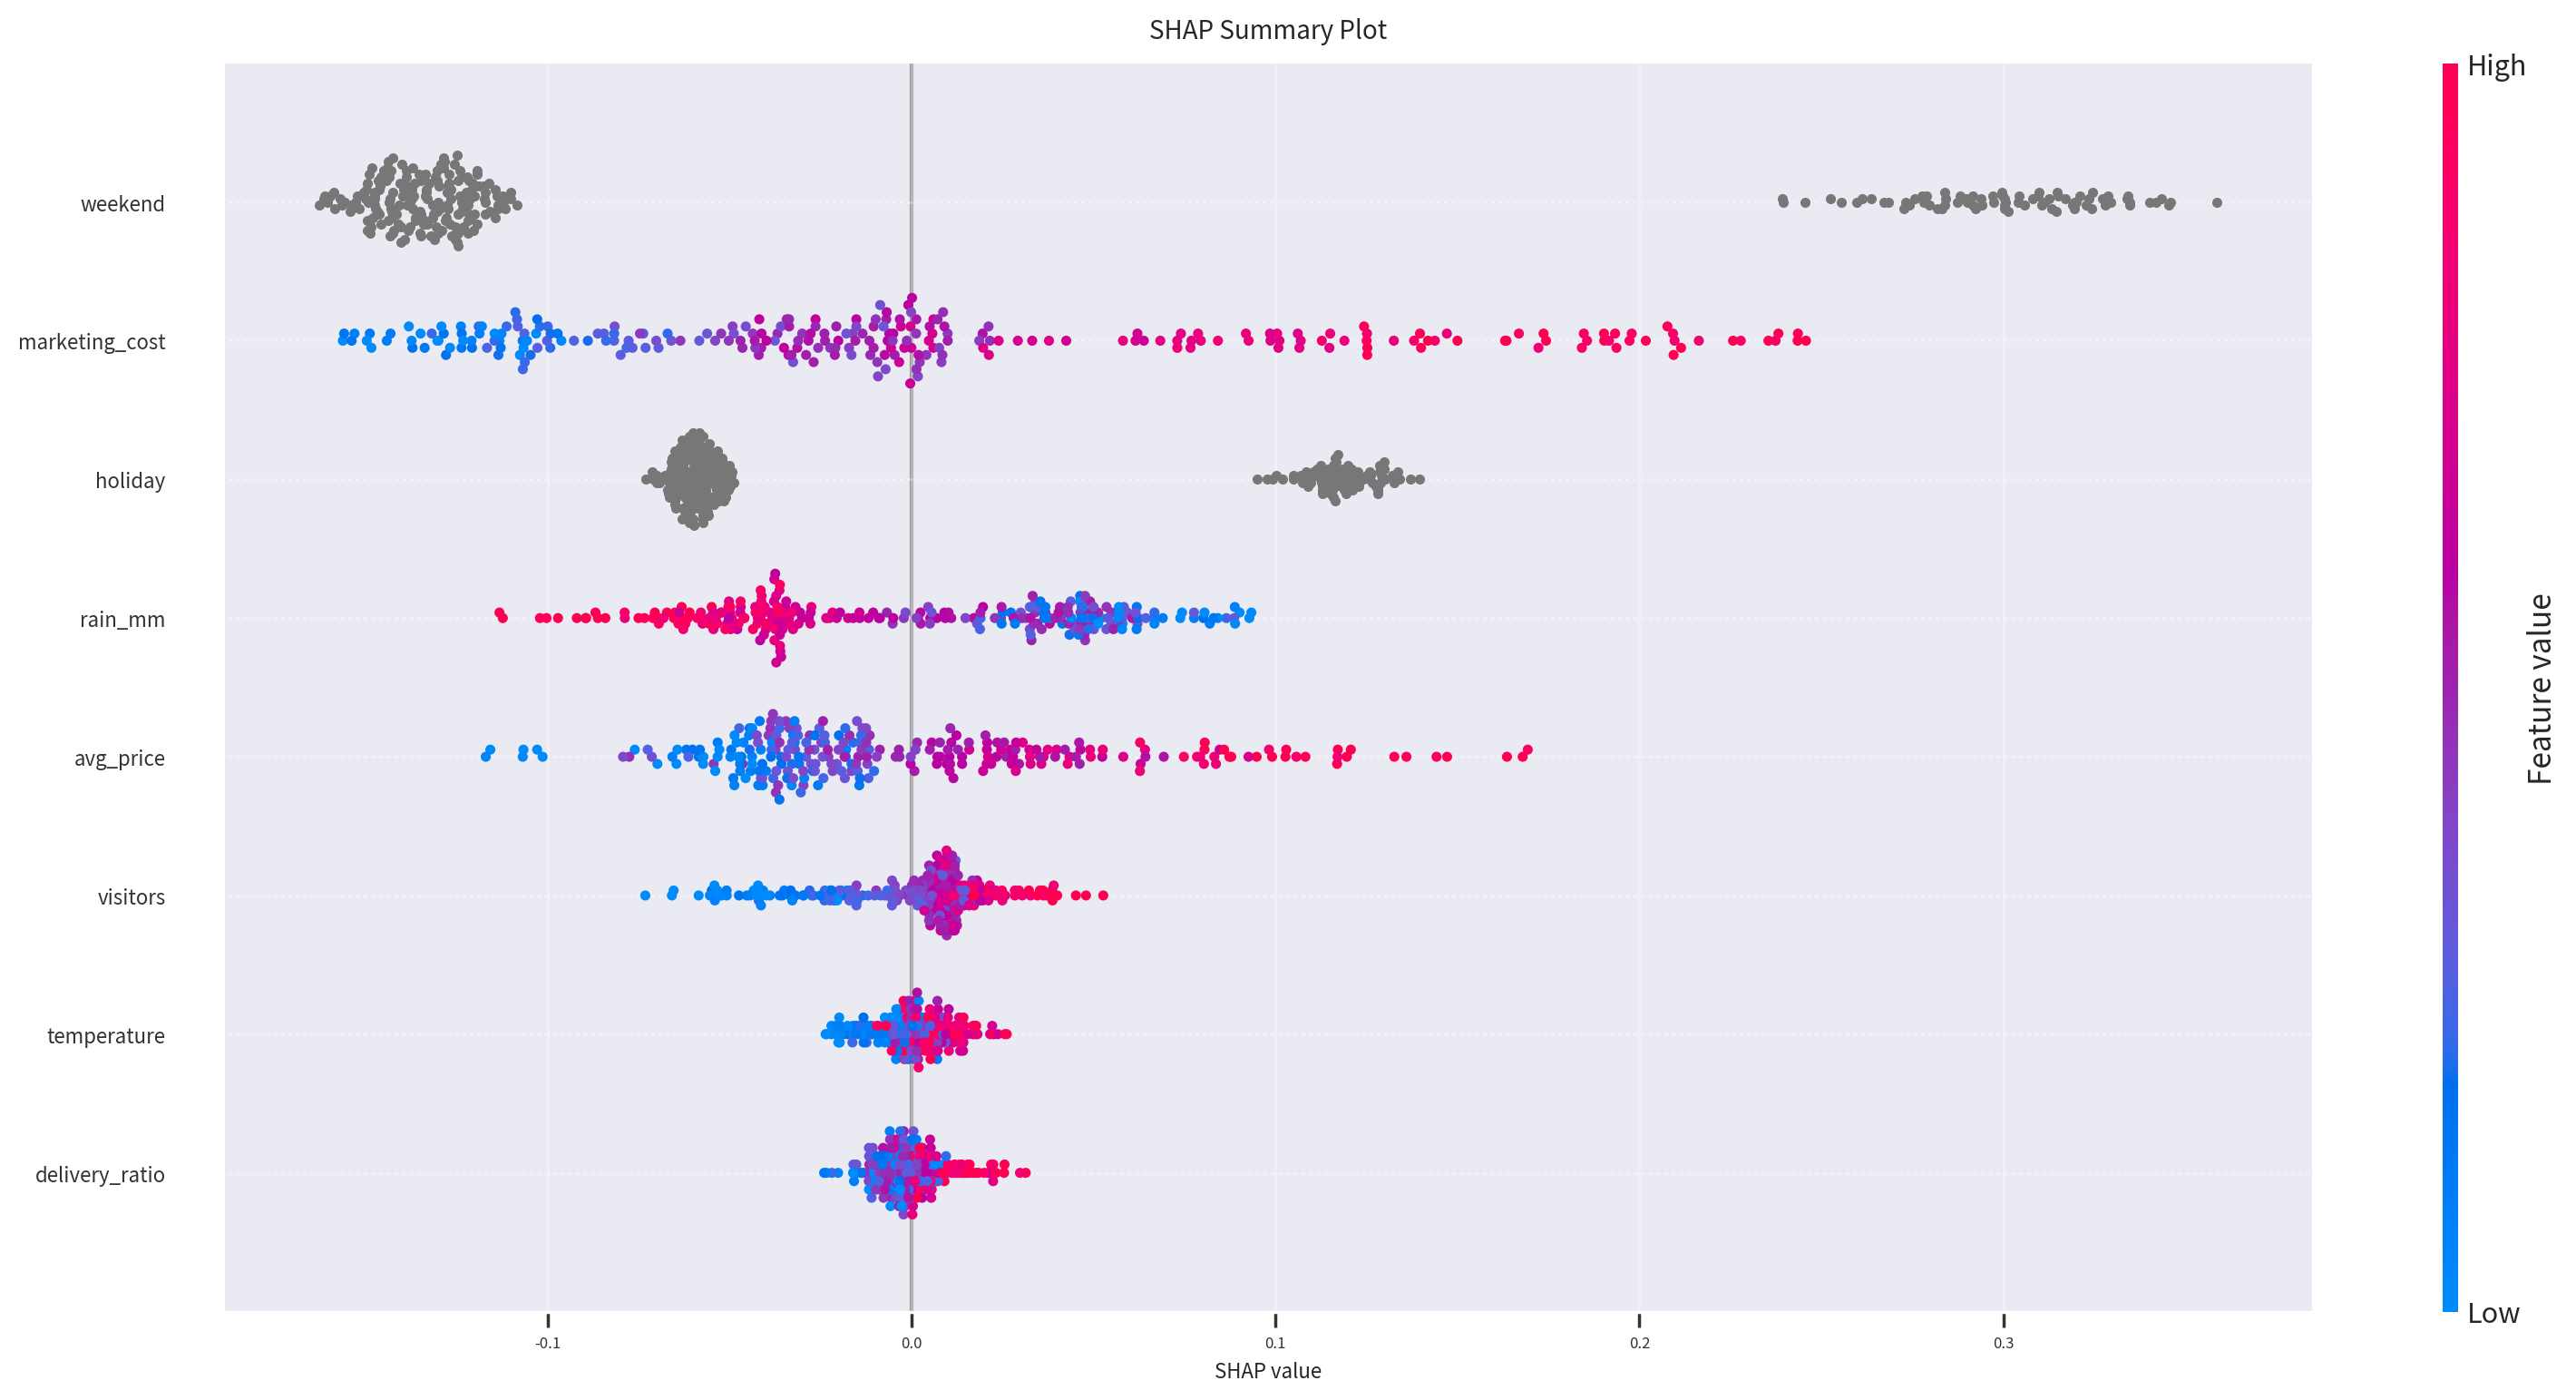

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,variability,importance_ratio,importance_cumsum,is_important
0,weekend,0.184,-0.004,0.200,음(-) 경향,1.088,variable,0.395,0.395,core
1,marketing_cost,0.081,0.001,0.104,양(+) 경향,1.277,variable,0.174,0.569,core
2,holiday,0.080,0.003,0.085,양(+) 경향,1.065,variable,0.171,0.740,core
3,rain_mm,0.046,-0.001,0.051,음(-) 경향,1.113,variable,0.098,0.838,secondary
4,avg_price,0.043,-0.002,0.054,음(-) 경향,1.252,variable,0.092,0.930,secondary
5,visitors,0.018,0.000,0.023,양(+) 경향,1.301,variable,0.038,0.969,secondary
6,temperature,0.008,0.000,0.010,양(+) 경향,1.291,variable,0.017,0.985,secondary
7,delivery_ratio,0.007,-0.000,0.009,음(-) 경향,1.328,variable,0.015,1.000,secondary


array([[ 0.01366157, -0.04865294, -0.00682275, -0.00855129, -0.04293852,
         0.00485115, -0.06237565, -0.13721416],
       [ 0.00531296,  0.08734606, -0.10821597, -0.00786912, -0.06816537,
         0.00306888, -0.06253319, -0.14253912],
       [-0.01564906, -0.03203023,  0.08419588,  0.00289335, -0.04069614,
        -0.02025376,  0.10970496,  0.29004481],
       [ 0.03225695,  0.02354357, -0.01133451, -0.00095103,  0.06209149,
        -0.00185498, -0.05164813, -0.1102291 ],
       [-0.03498917, -0.01167578, -0.00861744,  0.00689836, -0.04119851,
         0.00561855, -0.05633   , -0.13034683]])

In [51]:
summary_df, shap_values = hs_shap_analysis(best_model, x_train)

display(summary_df)
display(shap_values[:5])


#### SHAP summary_Df 를 기준으로 dependence_Plot 시각화 함수
- SHAP summary_df 를 기준으로
 1. dependence_Plot 대상 변수 쌍 자동 선정
 2. 모든 쌍에 대해 dependence plot 일괄 시각화


<코드 해석>
중요도가 높고 (core), 영향력이 상황에 따라 달라지는 (variable)  변수들을 기준으로
SHAP dependence pot 을 상호작용 후보 변수와 짝지어서 한번에 함수를 그리기 위한 코드,
변수 단독 효과와 상호작용 가능성을 한번에 보기위한 목적

1. main features 선정
   - 중요도가 높은 core 이면서, 영향력이 일정하지 않고 케이스에 따라 흔들리는 variable
   - 비선형, 상호작용 효과가 있는 가능성이 큰 항목들
2. interraction feature 선정
   - 메인 후보는 core 핵심 변수 이고, core 가 적으면 (2개 이하) secondary 까지 후보 확장
3. 주변수, 상호작용 변수 쌍 생성
   - main features 에 interaction gfeature 를 붙여, 자기 자신과의 조합을 제외한 모든 조합 생성
4. pairs 를 주변수 중요도 순서로 정렬
   - 가장 중요한 변수의 dependence plot 이 먼저 생성되도록
5. pairs 전부에 대해 dependence plot 자동 생성
   - depencence plot 을 통해, x 축은 feature name 의 실제 값, y 축은 feature 가 예측에 기여한 정도
   - 색상은 interaction_name 값
   - feature name 값이 커질수록 예측이 증가/감소 하는가?, 그 관계까 interaction name 에 따라 달라지는가? 확인


In [53]:
def hs_shap_dependence_analysis(
    summary_df: DataFrame,
    shap_values,
    x_train: DataFrame,
    include_secondary: bool = False, #core 변수가 너무 적을 때, True 로 설정하면 secondary 까지 포함
    width: int = 1600,
    height: int = 800,
):
    # 1. 주 대상 변수 (Core + Variable)
    main_features = summary_df[
        (summary_df["is_important"] == "core")
        & (summary_df["variability"] == "variable")
    ]["feature"].tolist()

    # 2. 상호작용 후보 변수
    interaction_features = summary_df[
        summary_df["is_important"] == "core"
    ]["feature"].tolist()

    if include_secondary and len(interaction_features) < 2:
        interaction_features.extend(
            summary_df[summary_df["is_important"] == "secondary"]["feature"].tolist()
        )

    # 3. 변수 쌍 생성 (자기 자신 제외)
    pairs = []
    for f in main_features:
        for inter in interaction_features:
            # 자기 자신과의 조합은 제외
            if f != inter:
                pairs.append((f, inter))

    # 중요도 순 정렬 (주 변수 기준)
    importance_rank = {}
    for i, row in summary_df.iterrows():
        importance_rank[row["feature"]] = i

    pairs = sorted(
        pairs,
        key=lambda x: importance_rank.get(x[0], 999),
    )

    # 4. dependence plot 일괄 생성
    for feature_name, interaction_name in pairs:
        shap.dependence_plot(
            feature_name,
            shap_values,
            x_train,
            interaction_index=interaction_name,
            show=False,
        )

        # SHAP figure 직접 제어
        fig = plt.gcf()
        fig.set_size_inches(width / my_dpi, height / my_dpi)

        plt.title(
            f"SHAP Dependence Plot: {feature_name} × {interaction_name}",
            fontsize=10,
            pad=10,
        )

        plt.xlabel(feature_name, fontsize=10)
        plt.ylabel(f"SHAP value for {feature_name}", fontsize=10)

        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    return pairs


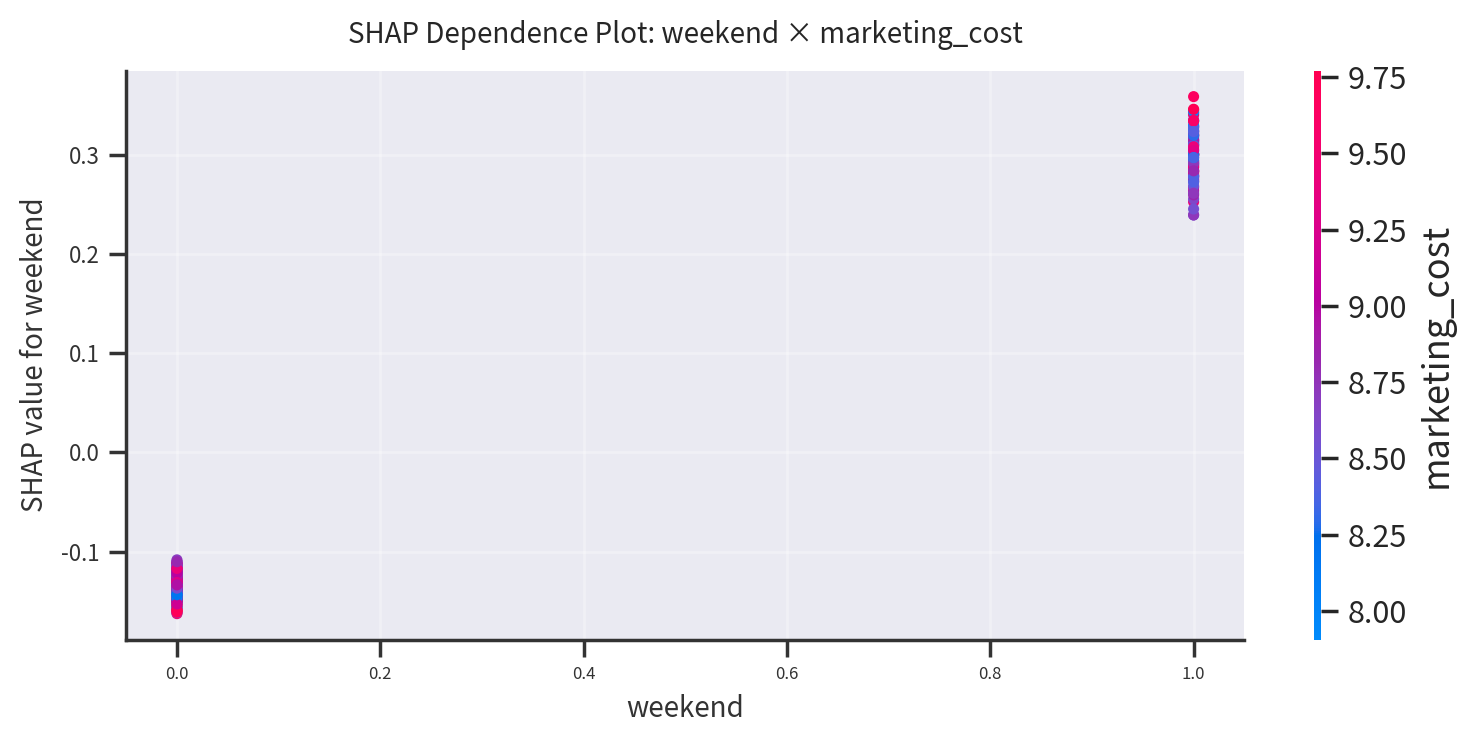

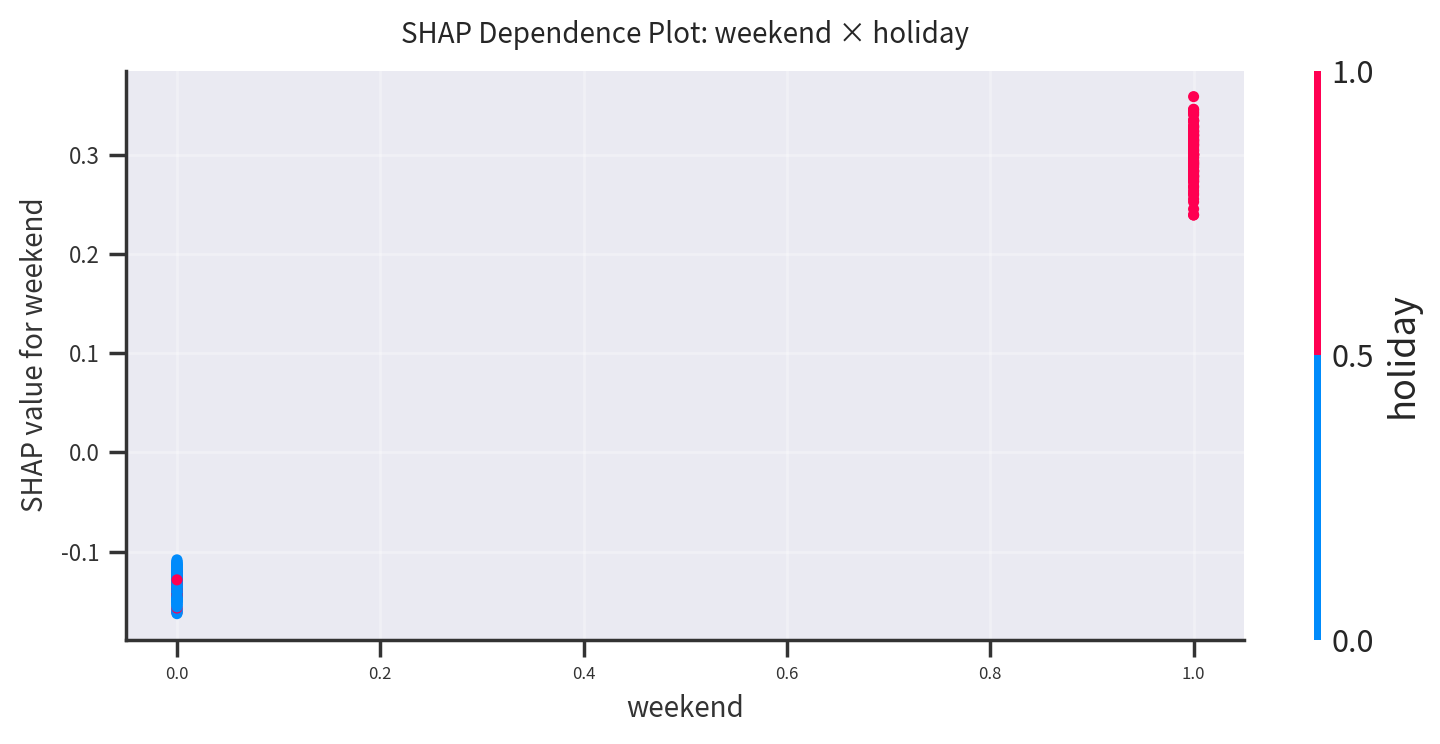

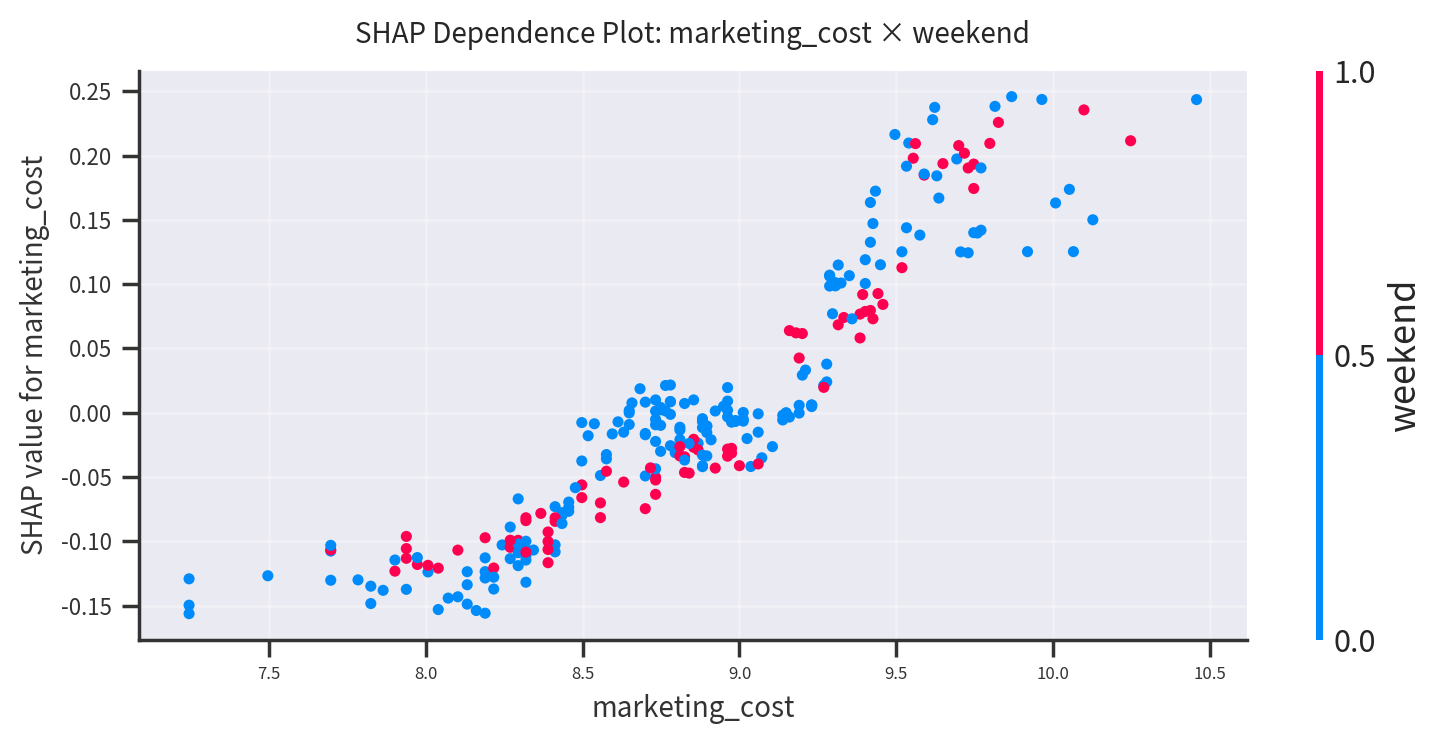

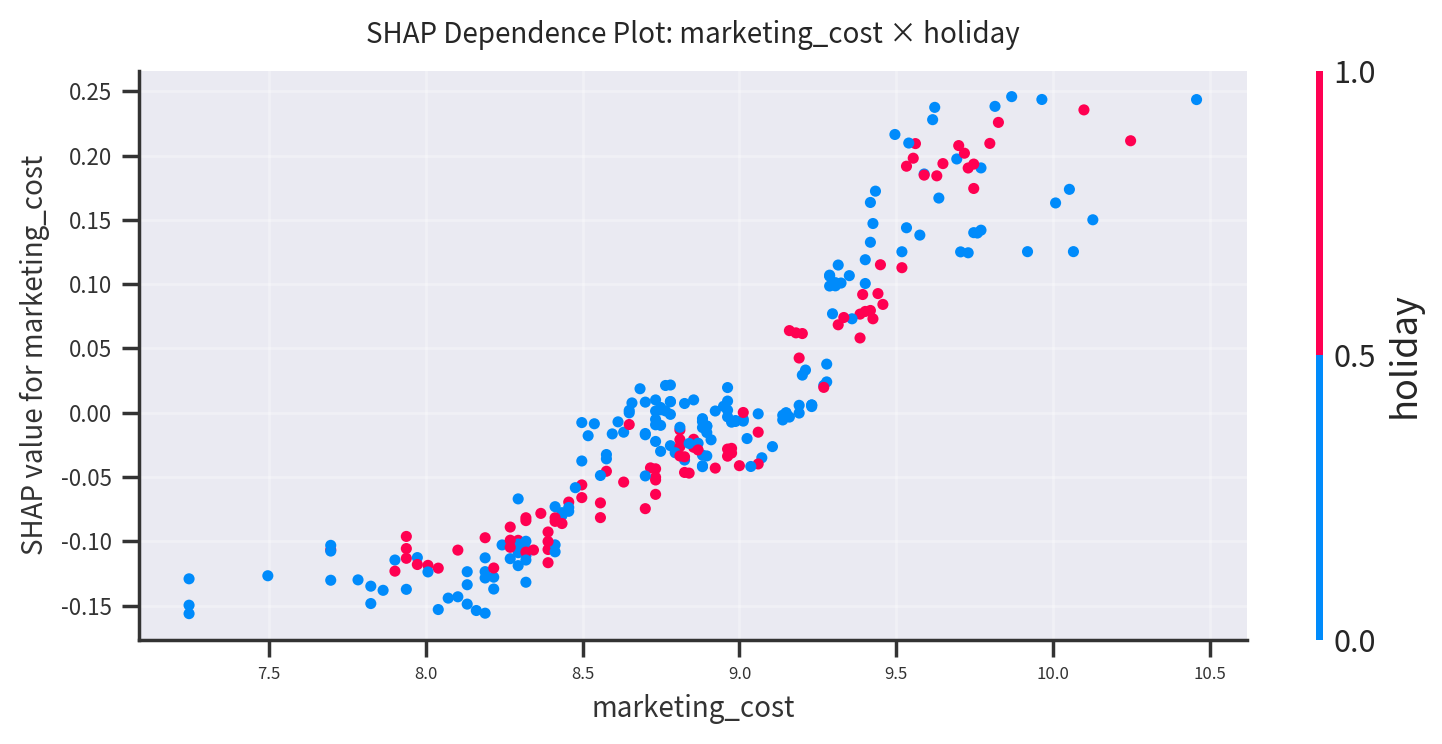

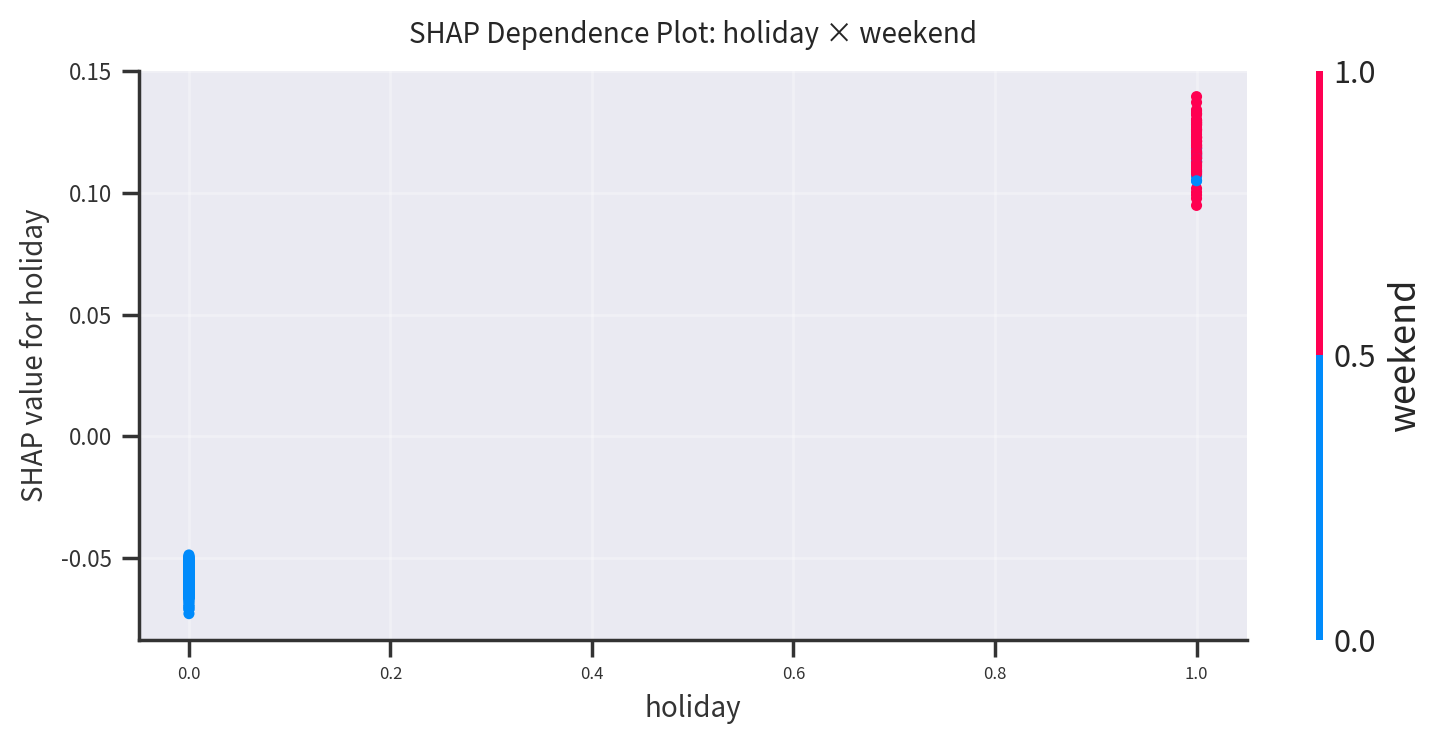

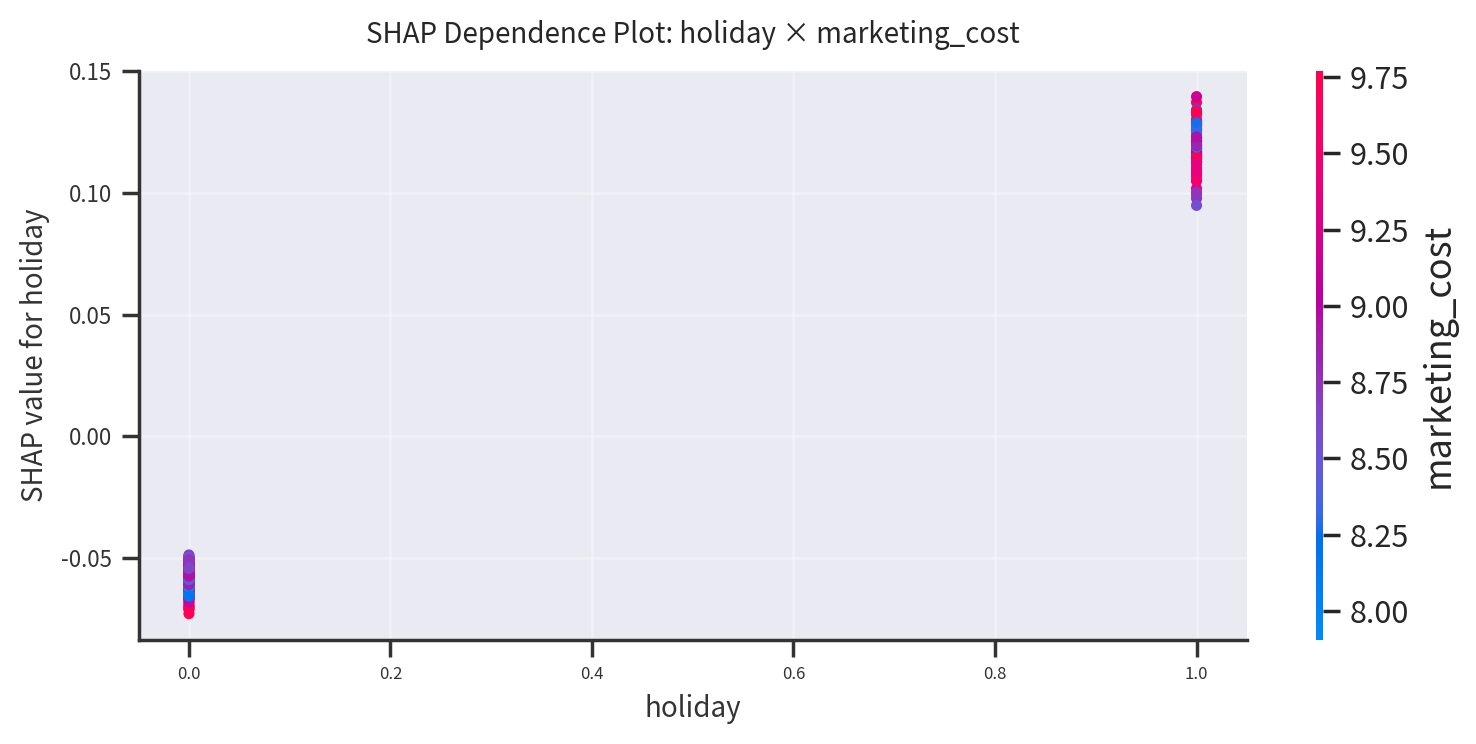

[('weekend', 'marketing_cost'),
 ('weekend', 'holiday'),
 ('marketing_cost', 'weekend'),
 ('marketing_cost', 'holiday'),
 ('holiday', 'weekend'),
 ('holiday', 'marketing_cost')]

In [54]:
hs_shap_dependence_analysis(summary_df,shap_values,x_train,include_secondary=False)

#### 인사이트

*SHAP에서 ‘예측값을 밀어 올린다 / 내린다’는 말은
평균 예측값을 기준으로 해당 변수가 예측을 어느 방향으로, 얼마나 이동시켰는지를 뜻한다
*SHAP 값이 보는건, 이 모델이 예측을 잘 했나요? 가 아니라, 이 예측이 왜 이렇게 나오게 나온거


오해하면 안되는 부분
- “SHAP 값이 크면 모델이 좋은 거 아닌가 -> X -> SHAP 값은 기여도, 성능이 아님.
- SHAP 값이 크면 예측력이 높은 변수인가> ->X -> 그건 그 변수의 영향력이지,
모델의 예측력 아님.

*같은 변수들 끼리더라도 주 변수가 바뀌면 그래프 모양이 달라짐

1. SHAP Dependence Plot: weekend × marketing_cost
- 이 모델은, 주말이라는 정보를 예측값을 만들 떄 어떻게 사용했나? (실제 주말의 효과가 아닌 모델의 생각 방식을 보여줌)

- x 축은 0 평일, 1 주말 | y 축은 SHAP value for weekend (weekend 가 예측값을 올렸는지, 내렸는지)
- 각 점은 관측치 1개를 의미
- 색상은 marketing_cost 의 크기

- 주말은 예측을 올리고 평일이면 무조건 예측을 내린다 
- 여기서 Y 의 -0.1, 0.3 같은 숫자는 마케팅의 효과 크기가 아니라, 예측을 어느 방향으로 밀었는가가 포인트임
- 색상이 달라져도 Y 값은 대부분 비슷한 수준 유지 > 주말 효과는 마케팅 비용이 크든 작든 상관없이 거의 동일하게 작용


2. SHAP Dependence Plot: marketing_cost × weekend